<a href="https://colab.research.google.com/github/Iurii-Ermakov/Game-analysis-on-the-play-game-store/blob/ermakovls/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%BF%D0%BE%D0%BF%D1%83%D0%BB%D1%8F%D1%80%D0%BD%D0%BE%D1%81%D1%82%D0%B8_%D0%B8_%D0%BC%D0%BE%D0%BD%D0%B5%D1%82%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D0%B8_%D0%B8%D0%B3%D1%80_%D0%B2_Google_Play_Store_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Анализ популярности и монетизации игр в Google Play Store
Задача проекта:


*   Проанализировать игры в датасете.
*   Рассчитать метрики (популярность, установки, монетизация).
*   Сравнить платные и бесплатные игры, чтобы подтвердить или опровергнуть гипотезу, что в платных играх выше рейтинг.
*   На основе выводов по гипотезе предложить рекомендации для разработчиков.

# Содержание

1.   Изучение данных из файла
2.   Подготовка данных
3.   Исследовательский анализ данных
4.   Новый пункт
5.   Проверка гипотез
6.   Общий вывод


# Изучение данных из файла

In [86]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from collections import Counter
import kagglehub
import os
import plotly.express as px
from scipy.stats import ttest_ind

In [46]:
# Скачивание датасета
path = kagglehub.dataset_download("lava18/google-play-store-apps")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/google-play-store-apps


In [47]:
# Проверка файлов в директории
files = os.listdir(path)
print("Files in directory:", files)

Files in directory: ['googleplaystore.csv', 'license.txt', 'googleplaystore_user_reviews.csv']


In [48]:
# Загрузка датасета
file_path = os.path.join(path, "googleplaystore.csv")
df = pd.read_csv(file_path, sep=',', encoding='latin1')  # Разделитель запятая, кодировка latin1

In [49]:
# функция для вывода некоторых основных данных по указанной таблице
def data_inform(data):
    display(data.head())
    data.info()
    df.describe().T
    print('\nКоличество пропущенных значений в столбцах:')
    display(data.isna().sum())
    print('\nЧисло дубликатов:', data.duplicated().sum())

In [50]:
data_inform(df)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite â FREE Live Cool Themes, Hid...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB

Количество пропущенных значений в столбцах:


,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0



Число дубликатов: 483


In [51]:
print(df['Category'].unique())

['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION' '1.9']


# Анализ датасета

Датасет содержит ~10k строк и 13 столбцов. Ключевые столбцы для анализа:

*  **App**: Название приложения.
*  **Category**: Категория (нужна GAME).
*  **Rating**: Рейтинг (0–5, есть пропуски).
*  **Reviews**: Количество отзывов (строка, нужно в int).
*  **Size**: Размер приложения (например, "19M", "100k", или "Varies with device").
*  **Installs**: Установки (например, "100,000+").
*  **Type**: Free/Paid.
*  **Price**: Цена (например, "$4.99" или "0").
*  **Genres**: Жанры (например, Action, Puzzle).
*  **Content Rating**: Возрастной рейтинг (например, Everyone, Teen).

Проблемы для очистки (на основе типичных проблем датасета):
*  Пропуски в Rating (~15% строк).
*  Некорректные форматы:
*  Installs: Строки с "+" и "," (например, "100,000+").
*  Price: Строки с валютой (например, "$4.99").
*  Size: Смешанные единицы ("19M", "100k", "Varies with device").
*  Reviews: Строки вместо чисел.
*  Возможные дубликаты приложений (App).
*  Некорректные строки (например, одна строка в датасете может быть сдвинута из-за ошибок ввода).
*  Пропуски или "NaN" в других столбцах (Type, Genres).

# Подготовка данных

Меня интересуют только игры, поэтому я произведу очистку данных и из предложенных приложений оставлю только категорию GAME

In [52]:
games = df[df['Category'] == 'GAME'].copy()
print(f"\nКоличество игр: {games.shape[0]}")


Количество игр: 1144


In [53]:
# Rating: заполню пропуски медианой
games['Rating'] = games['Rating'].fillna(games['Rating'].median())

In [54]:
# Type: заполняем пропуски как 'Free' (если мало пропусков, иначе удаляю)
games['Type'] = games['Type'].fillna('Free')

In [55]:
#Genres: удалю строки с пропусками (или заполню как 'Unknown')
games = games.dropna(subset=['Genres'])

In [56]:
# Проверка типа данных Installs
print("\nТип данных Installs:", games['Installs'].dtype)
print("Уникальные значения в Installs:\n", games['Installs'].unique())


Тип данных Installs: object
Уникальные значения в Installs:
 ['100,000,000+' '1,000,000,000+' '500,000,000+' '10,000,000+'
 '50,000,000+' '5,000,000+' '1,000,000+' '500,000+' '100,000+' '10,000+'
 '100+' '1,000+' '500+' '50,000+' '1+' '5,000+' '50+' '5+' '10+']


In [59]:
# Преобразование Installs
# Проверю, является ли столбец строковым
if games['Installs'].dtype == 'object':
    games['Installs'] = games['Installs'].str.replace('[+,]', '', regex=True).replace('Free', np.nan).astype(float)
else:
    # Если уже числовой, просто заменю 'Free' на NaN
    games['Installs'] = games['Installs'].replace('Free', np.nan).astype(float)

In [60]:
# Price: уберу '$', преобразую в float
if games['Price'].dtype == 'object':
    games['Price'] = games['Price'].str.replace('$', '').astype(float)
else:
    games['Price'] = games['Price'].astype(float)

In [61]:
# Reviews: преобразую в int
if games['Reviews'].dtype == 'object':
    games['Reviews'] = games['Reviews'].replace('Free', np.nan).astype(float).astype('Int64')  # Int64 поддерживает NaN
else:
    games['Reviews'] = games['Reviews'].astype('Int64')

In [62]:
# Size: преобразую в MB
def convert_size(size):
    if isinstance(size, str):
        if size.endswith('M'):
            return float(size.replace('M', ''))
        elif size.endswith('k'):
            return float(size.replace('k', '')) / 1024  # kB в MB
        elif size == 'Varies with device':
            return np.nan
        else:
            return np.nan
    return size

In [63]:
games['Size_MB'] = games['Size'].apply(convert_size)

Обработка пропусков

In [64]:
# Rating: заполню медианой
games['Rating'] = games['Rating'].fillna(games['Rating'].median())

In [65]:
# Type: заполню как 'Free'
games['Type'] = games['Type'].fillna('Free')

In [66]:
# Genres: удалю строки с пропусками
games = games.dropna(subset=['Genres'])

In [67]:
# Удалю дубликаты
games = games.drop_duplicates(subset=['App'], keep='first')
print(f"\nКоличество игр после удаления дубликатов: {games.shape[0]}")


Количество игр после удаления дубликатов: 960


In [68]:
# Проверка аномалий
# Удаляем строки с некорректным рейтингом (Rating > 5 или < 0)
games = games[(games['Rating'] >= 0) & (games['Rating'] <= 5)]

In [69]:
# Удалю строки с пропусками в Installs
games = games.dropna(subset=['Installs'])

In [71]:
# Сохраню очищенный датасета
games.to_csv('games_clean.csv', index=False)
print("\nОчищенный датасет сохранен как 'games_clean.csv'")


Очищенный датасет сохранен как 'games_clean.csv'


In [72]:
# Проверка финальных данных
print("\nПервые 5 строк очищенного датасета:\n", games[['App', 'Rating', 'Installs', 'Price', 'Genres', 'Size_MB']].head())
print("\nФинальная информация о датасете:\n")
games.info()


Первые 5 строк очищенного датасета:
                    App  Rating      Installs  Price  \
1653            ROBLOX     4.5  1.000000e+08    0.0   
1654    Subway Surfers     4.5  1.000000e+09    0.0   
1655  Candy Crush Saga     4.4  5.000000e+08    0.0   
1656         Solitaire     4.7  1.000000e+07    0.0   
1657    Bubble Shooter     4.5  1.000000e+07    0.0   

                            Genres  Size_MB  
1653  Adventure;Action & Adventure     67.0  
1654                        Arcade     76.0  
1655                        Casual     74.0  
1656                          Card     23.0  
1657                        Casual     46.0  

Финальная информация о датасете:

<class 'pandas.core.frame.DataFrame'>
Index: 960 entries, 1653 to 10804
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             960 non-null    object 
 1   Category        960 non-null    object 
 2   Rating          960 non-null  

In [73]:
check_df = pd.read_csv('games_clean.csv')
print(check_df.head())

                App Category  Rating   Reviews Size      Installs  Type  \
0            ROBLOX     GAME     4.5   4447388  67M  1.000000e+08  Free   
1    Subway Surfers     GAME     4.5  27722264  76M  1.000000e+09  Free   
2  Candy Crush Saga     GAME     4.4  22426677  74M  5.000000e+08  Free   
3         Solitaire     GAME     4.7    254258  23M  1.000000e+07  Free   
4    Bubble Shooter     GAME     4.5    148897  46M  1.000000e+07  Free   

   Price Content Rating                        Genres    Last Updated  \
0    0.0   Everyone 10+  Adventure;Action & Adventure   July 31, 2018   
1    0.0   Everyone 10+                        Arcade   July 12, 2018   
2    0.0       Everyone                        Casual    July 5, 2018   
3    0.0       Everyone                          Card  August 1, 2018   
4    0.0       Everyone                        Casual   July 17, 2018   

    Current Ver   Android Ver  Size_MB  
0  2.347.225742    4.1 and up     67.0  
1        1.90.0    4.1 and u

Данные подготовлены. Перехожу к исследованию

# Исследовательский анализ данных

In [74]:
# Загрузка очищенного датасета
games = pd.read_csv('games_clean.csv')

In [75]:
# Средний рейтинг по жанрам
rating_by_genre = games.groupby('Genres')['Rating'].mean().sort_values(ascending=False).head(10)

In [76]:
# Суммарные установки по жанрам
installs_by_genre = games.groupby('Genres')['Installs'].sum().sort_values(ascending=False).head(10)

In [77]:
# Доля платных игр
paid_share = games[games['Type'] == 'Paid'].shape[0] / games.shape[0]

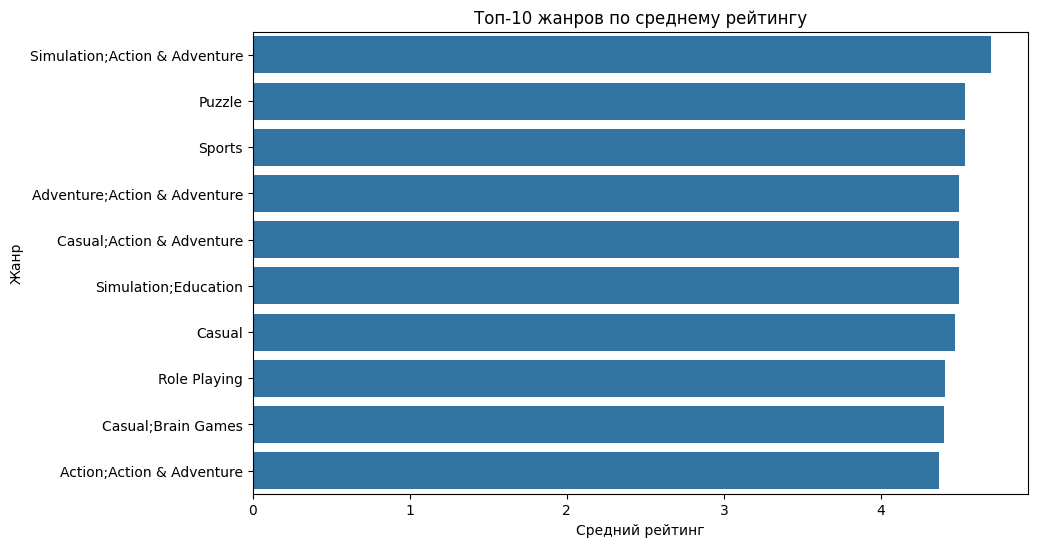

In [78]:
# Визуализация рейтинга
plt.figure(figsize=(10, 6))
sns.barplot(x=rating_by_genre.values, y=rating_by_genre.index)
plt.title('Топ-10 жанров по среднему рейтингу')
plt.xlabel('Средний рейтинг')
plt.ylabel('Жанр')
plt.show()

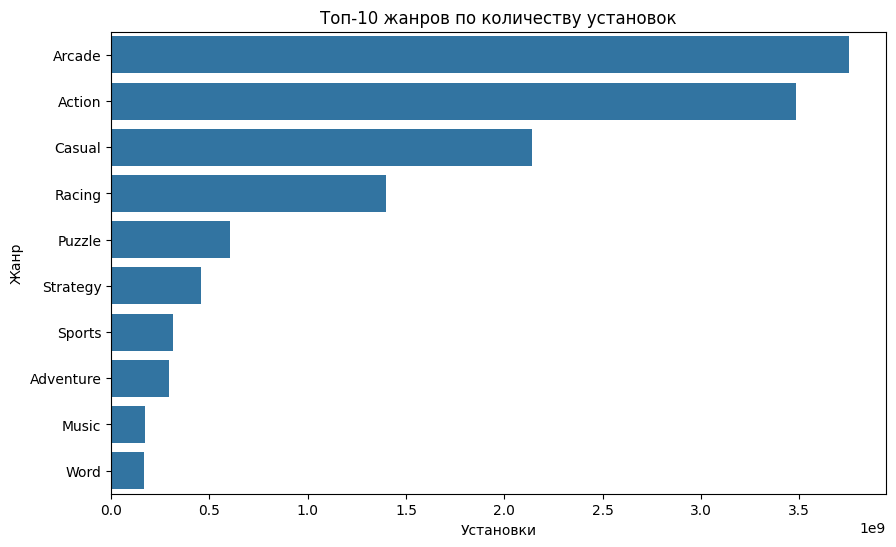

In [79]:
# Визуализация установок
plt.figure(figsize=(10, 6))
sns.barplot(x=installs_by_genre.values, y=installs_by_genre.index)
plt.title('Топ-10 жанров по количеству установок')
plt.xlabel('Установки')
plt.ylabel('Жанр')
plt.show()

In [80]:
print("Средний рейтинг по жанрам:\n", rating_by_genre)
print("\nУстановки по жанрам:\n", installs_by_genre)
print(f"\nДоля платных игр: {paid_share:.2%}")

Средний рейтинг по жанрам:
 Genres
Simulation;Action & Adventure    4.700000
Puzzle                           4.533333
Sports                           4.533333
Adventure;Action & Adventure     4.500000
Casual;Action & Adventure        4.500000
Simulation;Education             4.500000
Casual                           4.469565
Role Playing                     4.406667
Casual;Brain Games               4.400000
Action;Action & Adventure        4.366667
Name: Rating, dtype: float64

Установки по жанрам:
 Genres
Arcade       3.755129e+09
Action       3.483039e+09
Casual       2.139000e+09
Racing       1.400247e+09
Puzzle       6.032000e+08
Strategy     4.573000e+08
Sports       3.160000e+08
Adventure    2.966953e+08
Music        1.701205e+08
Word         1.691726e+08
Name: Installs, dtype: float64

Доля платных игр: 8.54%


In [82]:
# Фильтрация платных игр
paid_games = games[games['Type'] == 'Paid']

In [83]:
# ARPU по жанрам (топ-10)
arpu_by_genre = paid_games.groupby('Genres')['Price'].mean().sort_values(ascending=False).head(10).reset_index()

In [84]:
# Интерактивный барплот с Plotly
fig = px.bar(arpu_by_genre,
             x='Price',
             y='Genres',
             title='Топ-10 жанров по ARPU (платные игры)',
             labels={'Price': 'ARPU (USD)', 'Genres': 'Жанр'},
             color='Price',  # Цвет зависит от ARPU
             color_continuous_scale='Viridis',  # Цветовая схема
             text='Price',  # Показываем значения на столбцах
             height=600)
fig.update_traces(texttemplate='%{text:.2f}', textposition='auto')
fig.update_layout(xaxis_title='ARPU (USD)',
                  yaxis_title='Жанр',
                  showlegend=False,
                  title_x=0.5)
fig.show()

Хочу проверить гипотезу о томотличаются ли рейтинги платных и бесплатных игр

In [85]:
# Разделение на группы
paid_ratings = games[games['Type'] == 'Paid']['Rating']
free_ratings = games[games['Type'] == 'Free']['Rating']

In [87]:
# T-тест
t_stat, p_value = ttest_ind(paid_ratings, free_ratings, nan_policy='omit')
print(f"T-statistic: {t_stat:.2f}, P-value: {p_value:.4f}")
print("Вывод: ", "Рейтинги различаются (p < 0.05)" if p_value < 0.05 else "Рейтинги не различаются (p >= 0.05)")

T-statistic: 3.02, P-value: 0.0026
Вывод:  Рейтинги различаются (p < 0.05)


Построю график распределения рейтингов

In [88]:
# Интерактивный boxplot
fig = px.box(games,
             x='Type',
             y='Rating',
             title='Распределение рейтингов: Платные vs Бесплатные игры',
             labels={'Type': 'Тип игры', 'Rating': 'Рейтинг'},
             color='Type',  # Разные цвета для групп
             points='all',  # Показываем все точки
             height=600)
fig.update_layout(xaxis_title='Тип игры',
                  yaxis_title='Рейтинг',
                  title_x=0.5)
fig.show()

In [89]:
fig = px.scatter(games,
                 x='Rating',
                 y='Installs',
                 color='Genres',
                 size='Reviews',
                 hover_data=['App'],
                 title='Рейтинг vs Установки по жанрам',
                 log_y=True)  # Логарифмическая шкала для установок
fig.show()

Узнаю какая корреляция между рейтингом, установками и ценой

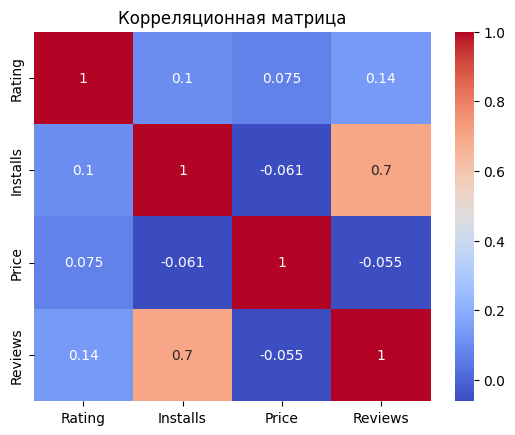

In [90]:
correlation = games[['Rating', 'Installs', 'Price', 'Reviews']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

Сильная корреляция между отзывами и установками указывает на важность пользовательской активности